# Dimensionality Reduction Part 2: Feature Extraction

## Principal Component Analysis (PCA)

Principal component analysis is a method that rotates the dataset in a way such that the rotated features are statistically uncorrelated. This rotation is often followed by selecting only a subset of the new features, according to how important they are for explaining the data. The following example illustrates the effect of PCA on a synthetic two-dimensional dataset:

<img src="images/pca.png" alt="PCA plots" width="800"/>

The first plot (top left) shows the original data points, colored to distinguish among them. The algorithm proceeds by first finding the direction of maximum variance, labeled “Component 1.” This is the direction (or vector) in the data that contains most of the information, or in other words, the direction along which the features are most correlated with each other. Then, the algorithm finds the direction that contains the most information while being orthogonal (at a right angle) to the first direction. In two dimensions, there is only one possible orientation that is at a right angle, but in higher-dimensional spaces there would be (infinitely) many orthogonal directions. Although the two components are drawn as arrows, it doesn’t really matter where the head and the tail are; we could have drawn the first component from the center up to the top left instead of down to the bottom right. The directions found using this process are called *principal components*, as they are the main directions of variance in the data. In general, there are as many principal components as original features.

The second plot (top right) shows the same data, but now rotated so that the first principal component aligns with the x-axis and the second principal component aligns with the y-axis. Before the rotation, the mean was subtracted from the data, so that the transformed data is centered around zero. In the rotated representation found by PCA, the two axes are uncorrelated, meaning that the correlation matrix of the data in this representation is zero except for the diagonal.

We can use PCA for dimensionality reduction by retaining only some of the principal components. In this example, we might keep only the first principal component, as shown in the third panel (bottom left). This reduces the data from a two-dimensional dataset to a one-dimensional dataset. Note, however, that instead of keeping only one of the original features, we found the most interesting direction (top left to bottom right in the first panel) and kept this direction, the first principal component.

Finally, we can undo the rotation and add the mean back to the data. This will result in the data shown in the last panel in the Figure. These points are in the original feature space, but we kept only the information contained in the first principal component. This transformation is sometimes used to remove noise effects from the data or visualize what part of the information is retained using the principal components.

#### APPLYING PCA TO THE CANCER DATASET FOR VISUALIZATION

One of the most common applications of PCA is visualizing high-dimensional datasets. As we know, it is hard to create scatter plots of data that has more than two features. For the Iris dataset, we were able to create a pair plot that gave us a partial picture of the data by showing us all the possible combinations of two features. But if we want to look at the Breast Cancer dataset, even using a pair plot is tricky. The breast cancer dataset has 30 features, which would result in 30 * 29 / 2 = 435 scatter plots (for just the upper triangle)! We’d never be able to look at all these plots in detail, let alone try to understand them.

There is an even simpler visualization we can use, though—computing histograms of each of the features for the two classes, benign and malignant cancer

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
dataframe = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
dataframe.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


/tmp/ipykernel_104267/2557764535.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm")


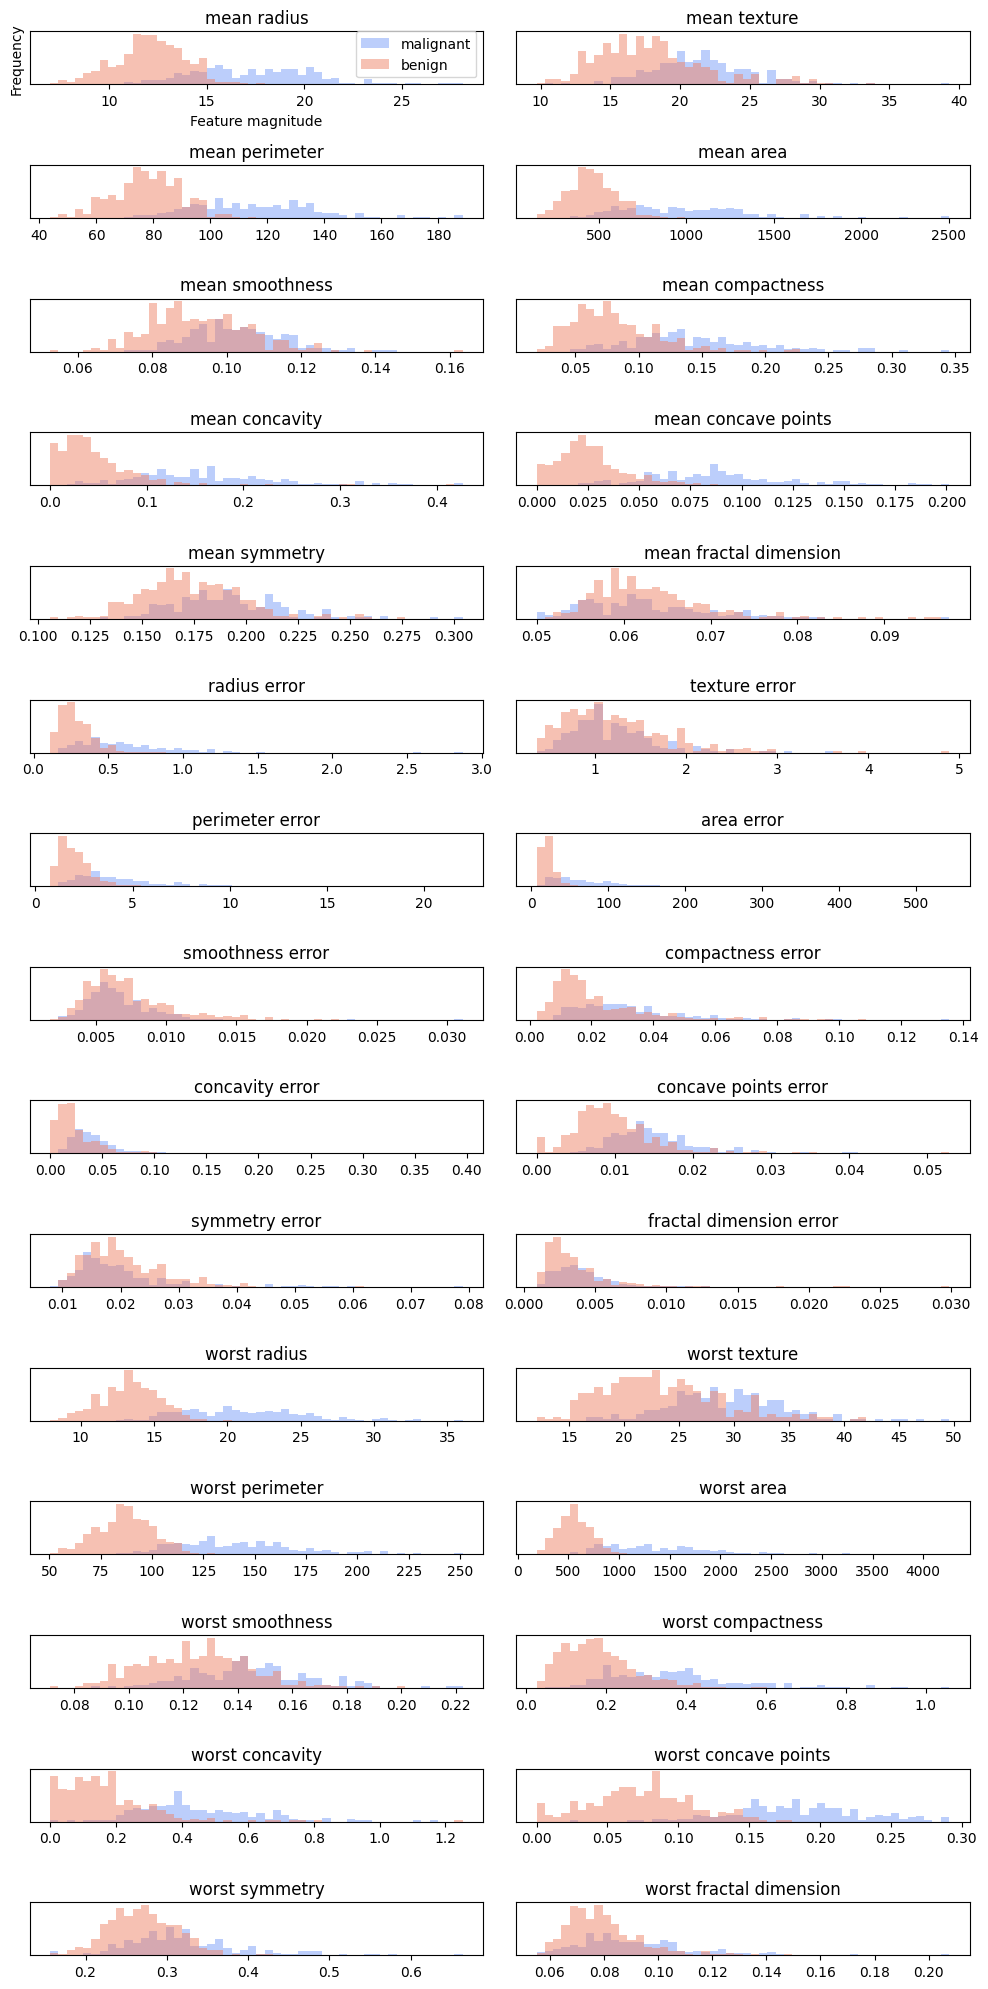

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()

# Use the built-in colormap from matplotlib
cmap = plt.cm.get_cmap("coolwarm")

for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color=cmap(0.2), alpha=.5)
    ax[i].hist(benign[:, i], bins=bins, color=cmap(0.8), alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())
ax[0].set_xlabel("Feature magnitude")
ax[0].set_ylabel("Frequency")
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()

plt.show()

Here we create a histogram for each of the features, counting how often a data point appears with a feature in a certain range (called a bin). Each plot overlays two histograms, one for all of the points in the benign class and one for all the points in the malignant class. This gives us some idea of how each feature is distributed across the two classes, and allows us to venture a guess as to which features are better at distinguishing malignant and benign samples. For example, the feature “smoothness error” seems quite uninformative, because the two histograms mostly overlap, while the feature “worst concave points” seems quite informative, because the histograms are quite disjoint.

However, this plot doesn’t show us anything about the interactions between variables and how these relate to the classes. Using PCA, we can capture the main interactions and get a slightly more complete picture. We can find the first two principal components, and visualize the data in this new two-dimensional space with a single scatter plot.

Before we apply PCA, we scale our data so that each feature has unit variance using `StandardScaler`:

In [3]:
# preprocessing using zero mean and unit variance scaling
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

Learning the PCA transformation and applying it is as simple as applying a preprocessing transformation. We instantiate the PCA object, find the principal components by calling the fit method, and then apply the rotation and dimensionality reduction by calling transform. By default, PCA only rotates (and shifts) the data, but keeps all principal components. To reduce the dimensionality of the data, we need to specify how many components we want to keep when creating the PCA object:

In [4]:
from sklearn.decomposition import PCA
# keep the first two principal components of the data
pca = PCA(n_components=2)
# fit PCA model to beast cancer data
pca.fit(X_scaled)

# transform data onto the first two principal components
X_pca = pca.transform(X_scaled)
print("Original shape: {}".format(str(X_scaled.shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

Original shape: (569, 30)
Reduced shape: (569, 2)


We can now plot the first two principal components

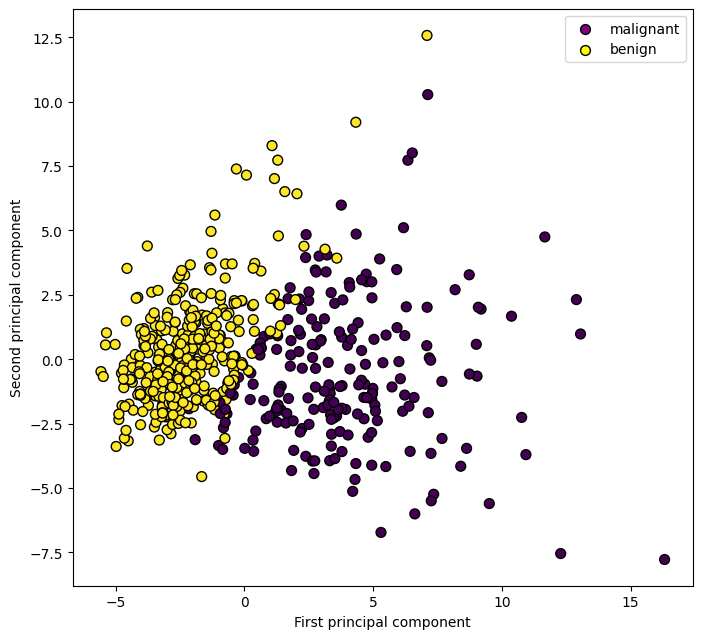

In [5]:
# plot first vs. second principal component, colored by class
plt.figure(figsize=(8, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cancer.target, cmap='viridis', edgecolor='k', s=50)

# Add legend
target_names = cancer.target_names
for target, color in zip(range(len(target_names)), ['purple', 'yellow']):
    plt.scatter([], [], c=color, s=50, label=target_names[target], edgecolor='k')

plt.legend(loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()

It is important to note that PCA is an unsupervised method, and does not use any class information when finding the rotation. It simply looks at the correlations in the data. For the scatter plot shown here, we plotted the first principal component against the second principal component, and then used the class information to color the points. You can see that the two classes separate quite well in this two-dimensional space. This leads us to believe that even a linear classifier (that would learn a line in this space) could do a reasonably good job at distinguishing the two classes. We can also see that the malignant points are more spread out than the benign points—something that we could already see a bit from the histograms.

A downside of PCA is that the two axes in the plot are often not very easy to interpret. The principal components correspond to directions in the original data, so they are combinations of the original features. However, these combinations are usually very complex, as we’ll see shortly. The principal components themselves are stored in the `components_` attribute of the PCA object during fitting:

In [6]:
print("PCA component shape: {}".format(pca.components_.shape))

PCA component shape: (2, 30)


Each row in components_ corresponds to one principal component, and they are sorted by their importance (the first principal component comes first, etc.). The columns correspond to the original features attribute of the PCA in this example, “mean radius,” “mean texture,” and so on. Let’s have a look at the content of `components_`:

In [7]:
print("PCA components:\n{}".format(pca.components_))

PCA components:
[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


We can also visualize the coefficients using a heat map, which might be easier to understand:

Text(0, 0.5, 'Principal components')

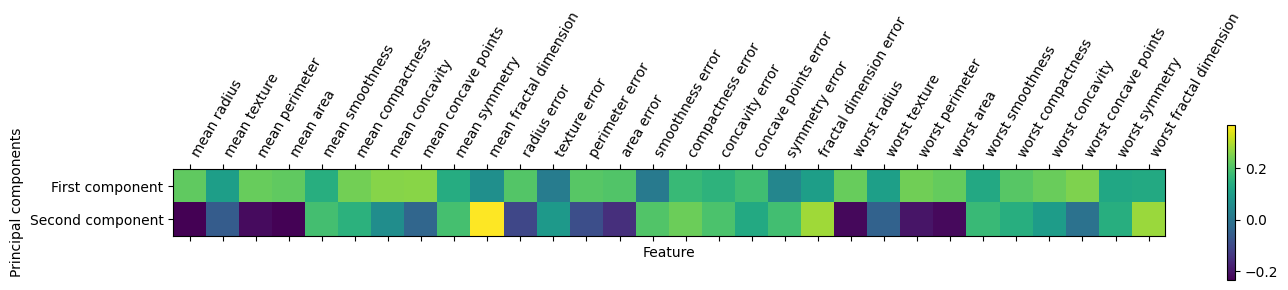

In [8]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")

### PCA in a Pipeline

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from mlxtend.data import wine_data

X, y = wine_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.3, stratify=y)

In [10]:
pipe1 = make_pipeline(StandardScaler(),
                     KNeighborsClassifier(n_neighbors=5))

pipe1.fit(X_train, y_train)

print('Orig. training accyracy: %.2f%%' % (pipe1.score(X_train, y_train)*100))
print('Orig. test accyracy: %.2f%%' % (pipe1.score(X_test, y_test)*100))

Orig. training accyracy: 99.19%
Orig. test accyracy: 92.59%


In [11]:
pipe_pca = make_pipeline(StandardScaler(),
                         PCA(n_components=3),
                         KNeighborsClassifier(n_neighbors=5))

pipe_pca.fit(X_train, y_train)


print('Transf. training accyracy: %.2f%%' % (pipe_pca.score(X_train, y_train)*100))
print('Transf. test accyracy: %.2f%%' % (pipe_pca.score(X_test, y_test)*100))

Transf. training accyracy: 96.77%
Transf. test accyracy: 96.30%


Note the reduced overfitting!

<br>
<br>

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

The MNIST dataset contains images of handwritten digits, each with 784 features (28 * 28 pixels).

In [12]:
from mlxtend.data import mnist_data

X, y = mnist_data()

We plot 15 of the images at random, along with their class labels:

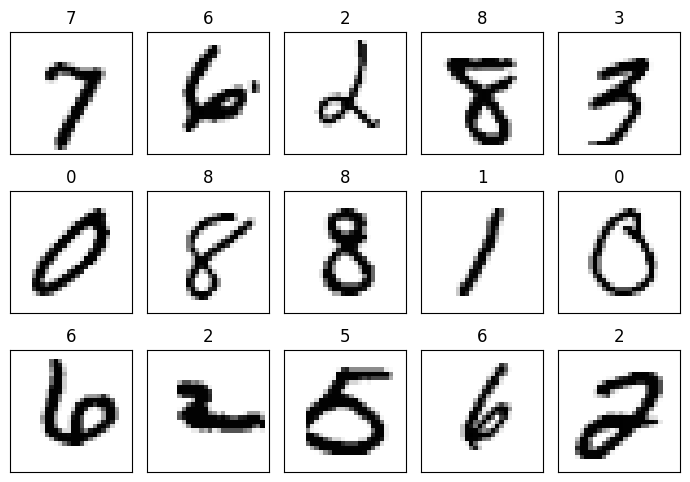

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline


nrows, ncols = 3, 5

rng = np.random.RandomState(123)
plt.figure(figsize=(7, 5))

for i in range(ncols * nrows):
    randint = rng.randint(0, 5000)
    ax = plt.subplot(nrows, ncols, i + 1)
    ax.matshow(X[randint].reshape(28, 28), cmap='Greys')
    plt.xticks([]); plt.yticks([])
    plt.title(y[randint])
    plt.tight_layout()

In [14]:
import matplotlib.patheffects as PathEffects


def plot_projection(x, colors):

    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')
    for i in range(0, 5000, 500):
        plt.scatter(x[i:i+500, 0], x[i:i+500, 1])

    ax.axis('off')
    ax.axis('tight')
    
    txts = []
    
    for i in range(10):

        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()])
        txts.append(txt)

Plot t-SNE visualization of the digits dataset with different perplexities

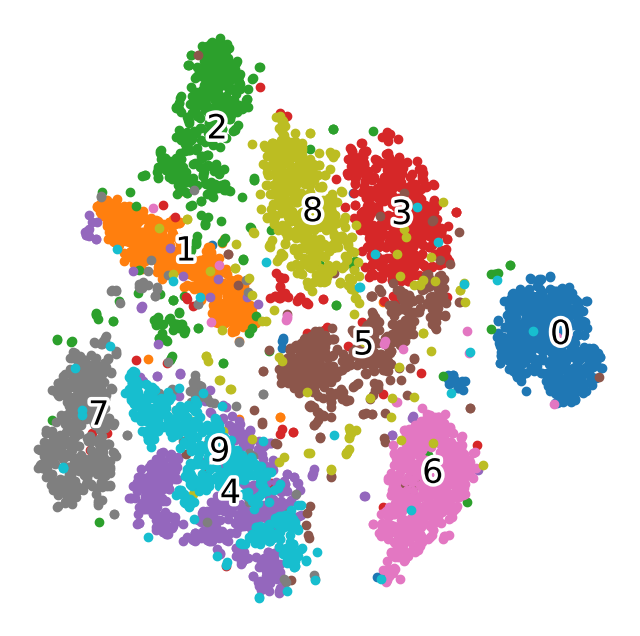

In [15]:
from sklearn.manifold import TSNE


projected = TSNE(n_components=2, perplexity=50.0, learning_rate=200, random_state=123).fit_transform(X)

plot_projection(projected, y)

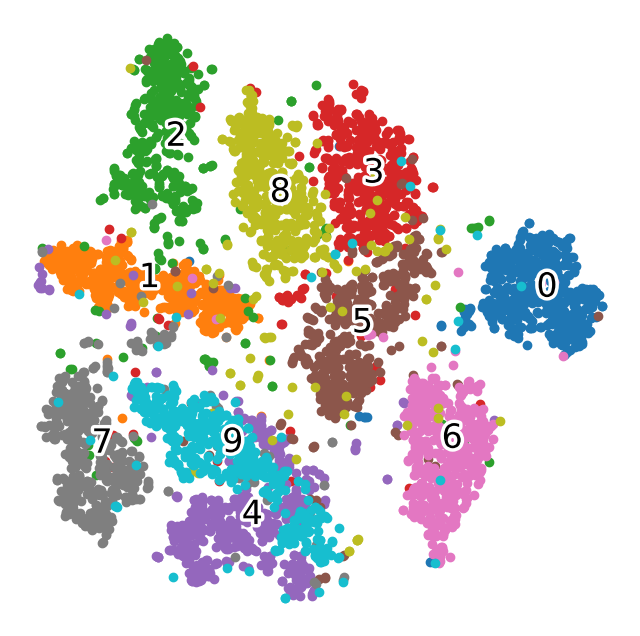

In [16]:
projected = TSNE(n_components=2, perplexity=30.0, learning_rate=200, random_state=123).fit_transform(X)

plot_projection(projected, y)

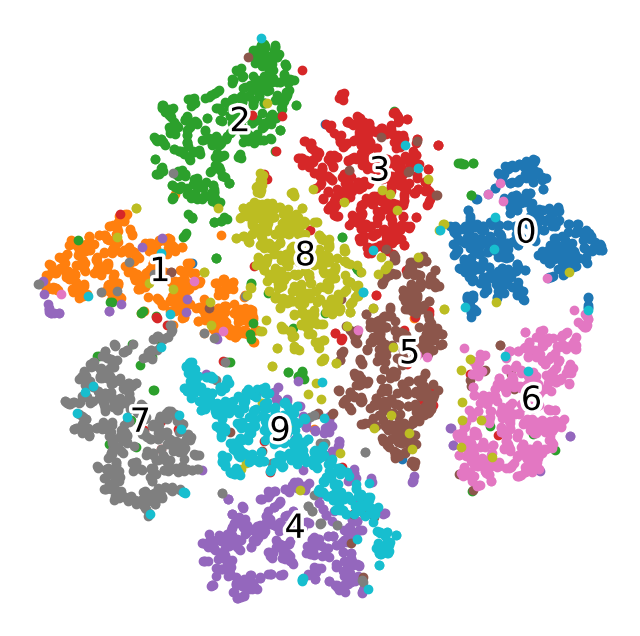

In [17]:
projected = TSNE(n_components=2, perplexity=10.0, learning_rate=200, random_state=123).fit_transform(X)

plot_projection(projected, y)

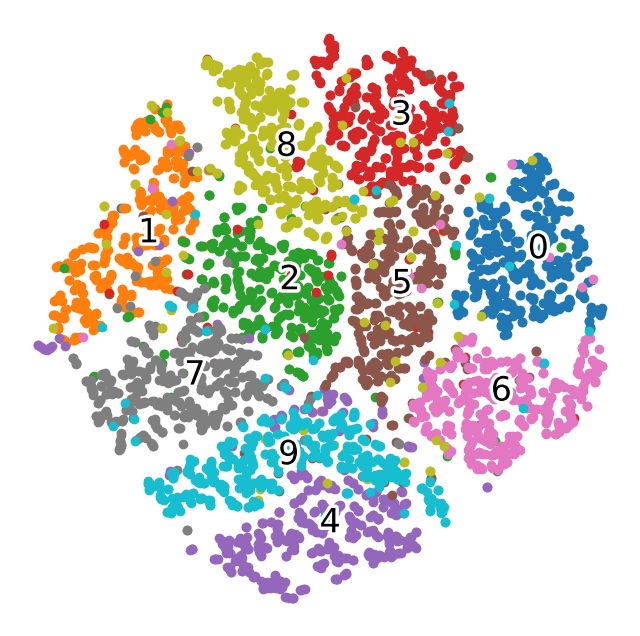

In [18]:
projected = TSNE(n_components=2, perplexity=5.0, learning_rate=200, random_state=123).fit_transform(X)

plot_projection(projected, y)